<a href="https://colab.research.google.com/github/Aryansinghparmar2321/OSSLab_241B048/blob/main/LAB_2(OSS).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


print("Download the datasets from internet")

credit_data = fetch_openml(
    data_id=1597,
    as_frame=True,
    parser='auto'
)

print("Download the datasets from internet")

df = credit_data.frame

print(f"Data shape (Rows, Columns): {df.shape}")

Download the datasets from internet
Download the datasets from internet
Data shape (Rows, Columns): (284807, 30)


In [3]:
df['Class'] = df['Class'].astype(int)

print("Class distribution in data:\n",
      df['Class'].value_counts())

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- SMOTE ---")

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print(
    "After SMOTE size of data:",
    pd.Series(y_train_smote).value_counts()
)

Class distribution in data:
 Class
0    284315
1       492
Name: count, dtype: int64

--- SMOTE ---
After SMOTE size of data: Class
0    227451
1    227451
Name: count, dtype: int64


In [6]:
ml_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=10,
        random_state=42,
        n_jobs=-1
    ),

    'Logistic Regression': LogisticRegression(
        max_iter=500,
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),

    'SVM': LinearSVC(
        random_state=42,
        dual=False,
        max_iter=2000
    ),

    'Naive Bayes': GaussianNB()
}

print("\n--- 3. Training of machine learning models... ---")

real_model_names = []
real_accuracy_scores = []
real_recall_scores = []

for name, model in ml_models.items():

    print(f"Training: {name}...")

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_scaled)

    real_model_names.append(name)

    real_accuracy_scores.append(
        accuracy_score(y_test, y_pred) * 100
    )

    real_recall_scores.append(
        recall_score(y_test, y_pred) * 100
    )


--- 3. Training of machine learning models... ---
Training: Random Forest...
Training: Logistic Regression...
Training: Decision Tree...
Training: SVM...
Training: Naive Bayes...


In [7]:
print("\n--- 4. (Neural Network) Training... ---")

ann_real = Sequential([
    Dense(
        32,
        activation='relu',
        input_shape=(X_train_smote.shape[1],)
    ),

    Dropout(0.2),

    Dense(
        16,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

ann_real.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_real.fit(
    X_train_smote,
    y_train_smote,
    epochs=5,
    batch_size=128,
    verbose=0
)

ann_prob = ann_real.predict(X_test_scaled).flatten()

y_pred_ann = np.where(
    ann_prob > 0.5,
    1,
    0
)

real_model_names.append('Neural Network')

real_accuracy_scores.append(
    accuracy_score(y_test, y_pred_ann) * 100
)

real_recall_scores.append(
    recall_score(y_test, y_pred_ann) * 100
)


--- 4. (Neural Network) Training... ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [8]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

for name, model in ml_models.items():

    print(f"\n{'='*60}")
    print(f"Algorithm: {name}")
    print(f"{'='*60}")

    # Training without SMOTE
    print(f"\n--- [1] {name} (without smote) ---")

    model.fit(X_train_scaled, y_train)

    y_pred_no_smote = model.predict(X_test_scaled)

    print(
        classification_report(
            y_test,
            y_pred_no_smote
        )
    )

    # Training with SMOTE
    print(f"--- [2] {name} (with smote) ---")

    model.fit(
        X_train_smote,
        y_train_smote
    )

    y_pred_with_smote = model.predict(X_test_scaled)

    print(
        classification_report(
            y_test,
            y_pred_with_smote
        )
    )


Algorithm: Random Forest

--- [1] Random Forest (without smote) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.77      0.85        98

    accuracy                           1.00     56962
   macro avg       0.97      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

--- [2] Random Forest (with smote) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962


Algorithm: Logistic Regression

--- [1] Logistic Regression (without smote) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72     

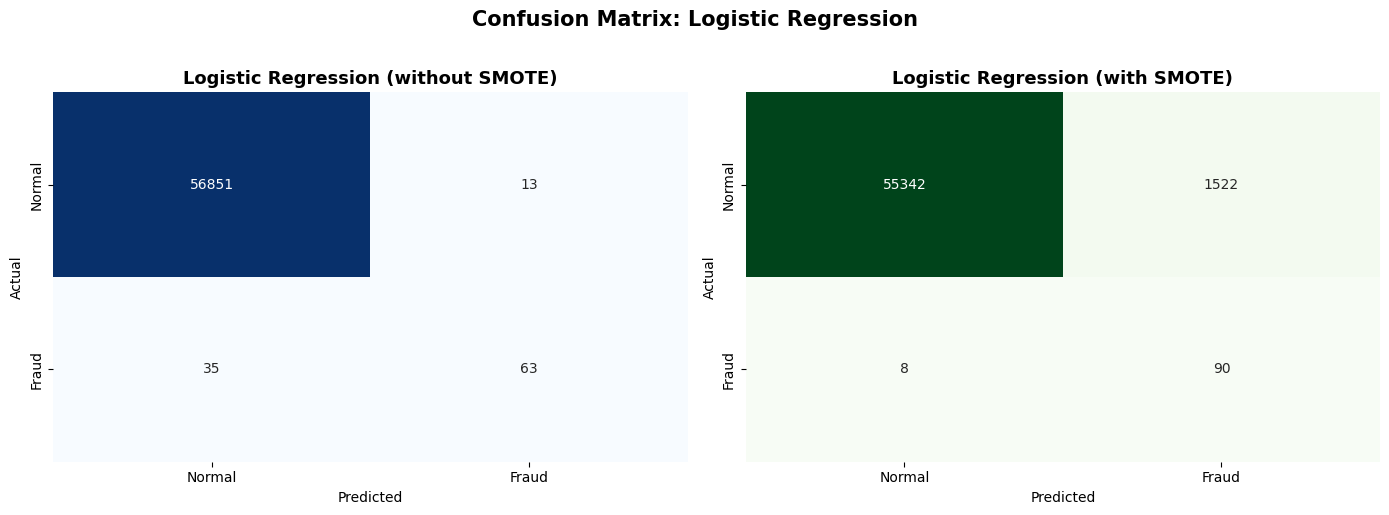

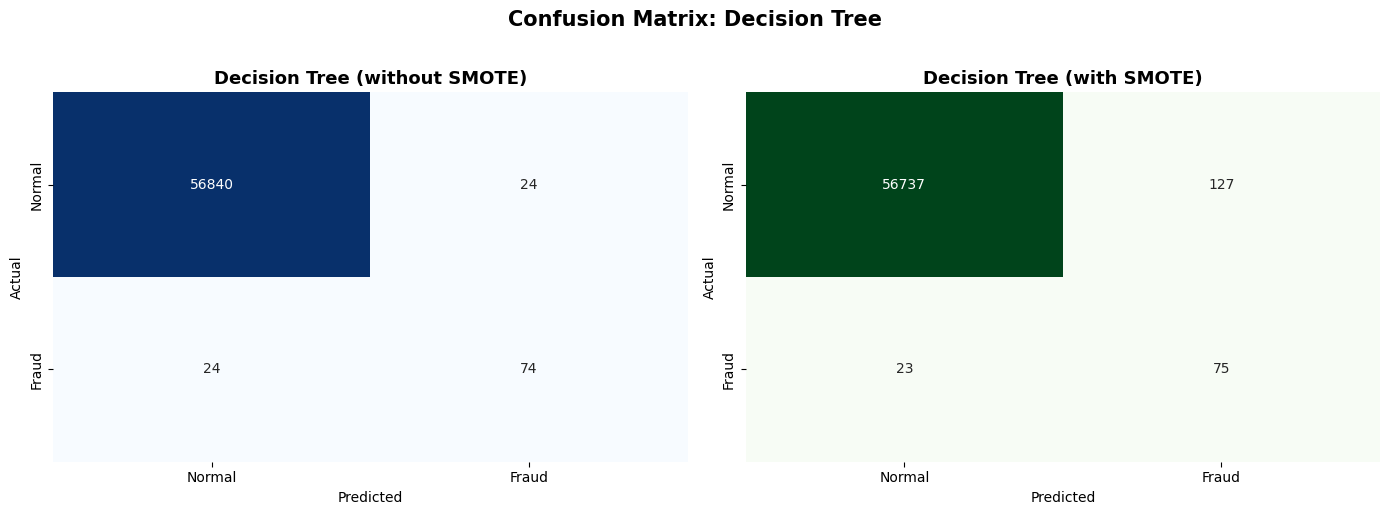

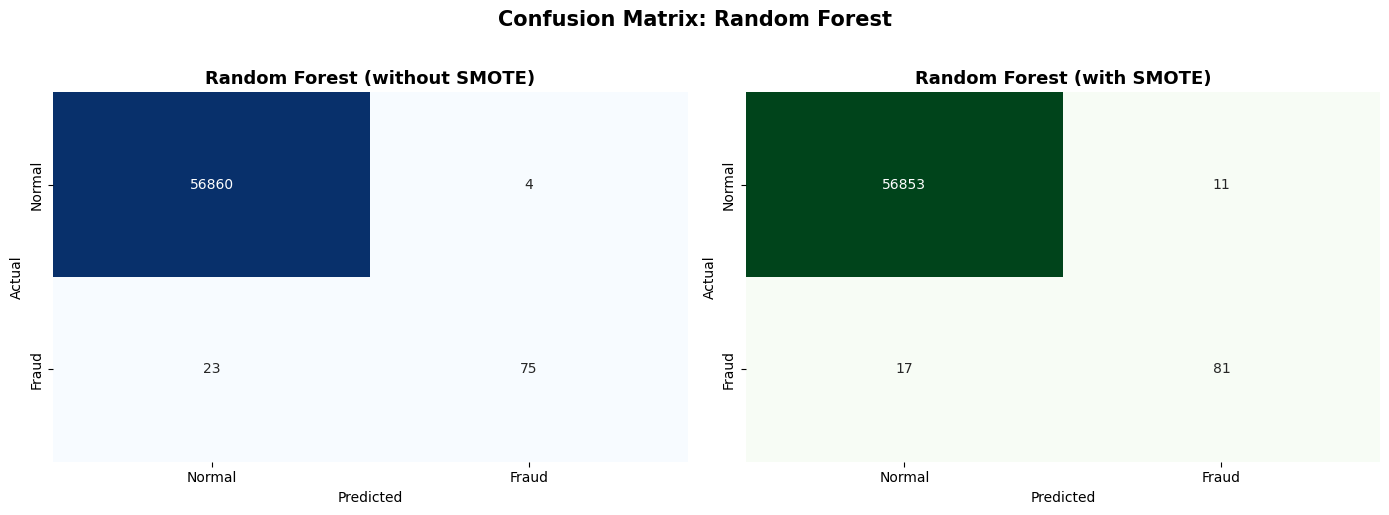

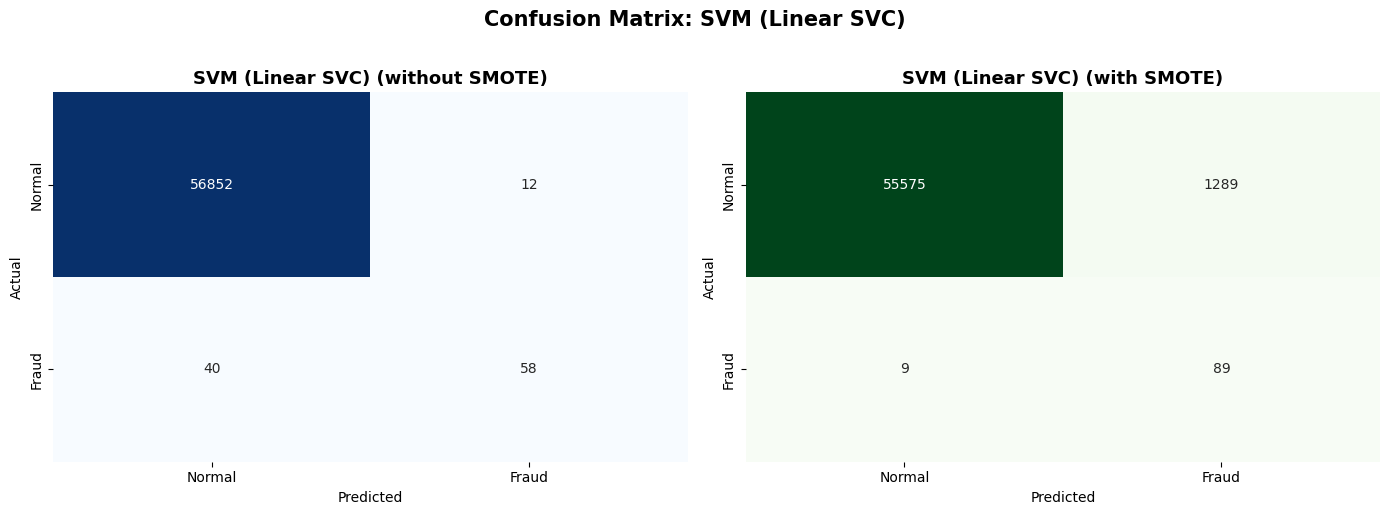

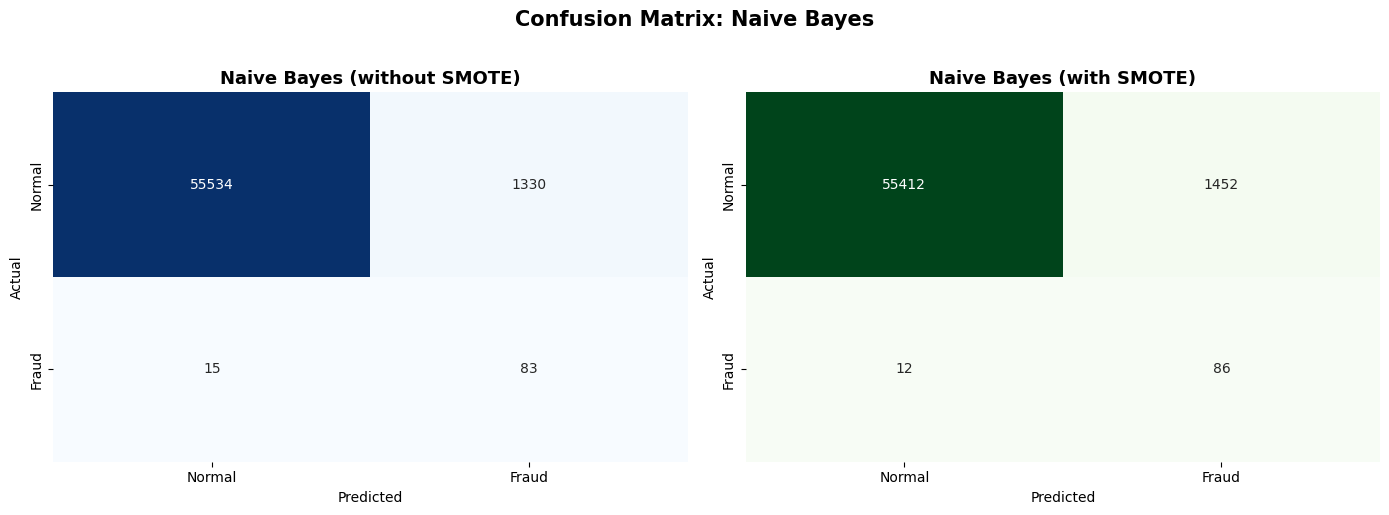

In [9]:
ml_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=500,
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=10,
        random_state=42,
        n_jobs=-1
    ),

    'SVM (Linear SVC)': LinearSVC(
        random_state=42,
        dual=False,
        max_iter=2000
    ),

    'Naive Bayes': GaussianNB()
}

for name, model in ml_models.items():

    # Without SMOTE
    model.fit(
        X_train_scaled,
        y_train
    )

    y_pred_no_smote = model.predict(
        X_test_scaled
    )

    cm_no_smote = confusion_matrix(
        y_test,
        y_pred_no_smote
    )

    # With SMOTE
    model.fit(
        X_train_smote,
        y_train_smote
    )

    y_pred_with_smote = model.predict(
        X_test_scaled
    )

    cm_with_smote = confusion_matrix(
        y_test,
        y_pred_with_smote
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    # Graph with SMOTE
    sns.heatmap(
        cm_no_smote,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=axes[0],
        xticklabels=['Normal', 'Fraud'],
        yticklabels=['Normal', 'Fraud']
    )

    axes[0].set_title(
        f'{name} (without SMOTE)',
        fontsize=13,
        fontweight='bold'
    )

    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # Graph with SMOTE
    sns.heatmap(
        cm_with_smote,
        annot=True,
        fmt='d',
        cmap='Greens',
        cbar=False,
        ax=axes[1],
        xticklabels=['Normal', 'Fraud'],
        yticklabels=['Normal', 'Fraud']
    )

    axes[1].set_title(
        f'{name} (with SMOTE)',
        fontsize=13,
        fontweight='bold'
    )

    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

    plt.suptitle(
        f"Confusion Matrix: {name}",
        fontsize=15,
        fontweight='bold',
        y=1.02
    )

    plt.tight_layout()
    plt.show()